In [1]:
import ROOT as rt
# import root_numpy as rtnp
import csv
import re
import sys
import collections
import os
from collections import OrderedDict
import uproot
import pandas as pd
import awkward as ak

import scipy
import awkward
import numpy as np
import time
import numba
from numba import jit
from matplotlib import pyplot as plt
import subprocess
GIT_REPO = subprocess.Popen(['git', 'rev-parse', '--show-toplevel'], stdout=subprocess.PIPE).communicate()[0].rstrip().decode('utf-8')
sys.path.append(GIT_REPO + '/lib/')
from histo_utilities import create_TH1D, create_TH2D, std_color_list, create_TGraph, make_ratio_plot

import CMS_lumi, tdrstyle
a = tdrstyle.setTDRStyle()
CMS_lumi.writeExtraText = 0

wH = 1
Z_MASS = 91.2


# donotdelete = []
print(sys.version)

Welcome to JupyROOT 6.24/06
3.6.8 (default, Nov  2 2021, 13:01:57) 
[GCC 8.4.1 20200928 (Red Hat 8.4.1-1)]


# Load ntuples

In [2]:
samples = [
#     'STodd_ms3p0',
    # 'SToEE_ms0p4',
#     'SToGammaGamma_ms0p4',
#     'SToKPlusKMinus_ms1p5',
#     'SToK0K0_ms1p5',
#     'SToPi0Pi0_ms0p4',
#     'SToPi0Pi0_ms1p0',
#     'SToPiPlusPiMinus_ms0p4',
#     'SToPiPlusPiMinus_ms1p0',

#     'dddd_MH-125_MS-15',
    '4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted',
    '4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted',
#     'dddd_MH-125_MS-55',
    
#     'bbbb_MH-125_MS-15',
#     'bbbb_MH-125_MS-40',
#     'bbbb_MH-125_MS-55',
    
#     '4Tau_MH-125_MS-7',
#     '4Tau_MH-125_MS-15',
    '4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted',
#     '4Tau_MH-125_MS-55',
#     'dddd_MH-125_MS-7',
# '4B_MH-125-MS-15-ctauS-100000_TuneCP5_13p6TeV_powheg-pythia8_23020pb_weighted',
]

In [5]:
%%time

import uproot
import numpy as np

r_csc = {}
r_dt = {}
z_csc = {}
z_dt = {}
    
llp_r = {}
llp_z = {}
    
llp_r_dt = {}
llp_z_dt = {}
    
llp_r_csc = {}
llp_z_csc = {}
r_dt_cluster = {}
z_dt_cluster = {}
weight_llp = {}
for sample in samples:
    m = sample

    
    r_csc[m] = []
    r_dt[m] = []
    z_csc[m] = []
    z_dt[m] = []
    llp_r[m] = []
    llp_z[m] =[]
    llp_r_dt[m] = []
    llp_z_dt[m] =[]
    llp_r_csc[m] = []
    llp_z_csc[m] =[]
    weight_llp[m] = []
    r_dt_cluster[m] = []
    z_dt_cluster[m] = []
    print(m)
#     if 'dd' not in sample:continue
    version = 'v24'
    path = f"/storage/af/group/phys_exotica/delayedjets/displacedJetMuonAnalyzer/Run3/V1p19/MC_all/{version}/normalized/"
    root_dir =uproot.open(path+"ggH_Hto2Sto"+sample+".root")

    
    T = root_dir['MuonSystem']
    

    ########### SELECTION: EVENTS ############

    
#     sel_dt = np.logical_and(T['gLLP_decay_vertex_r'].array()>200, T['gLLP_decay_vertex_r'].array()<800)
#     sel_dt = np.logical_and(sel_dt, np.abs(T['gLLP_decay_vertex_z'].array())<700)
#     sel_csc = np.logical_and(np.abs(T['gLLP_eta'].array())<3, np.abs(T['gLLP_decay_vertex_z'].array())<1200)
#     sel_csc = np.logical_and(sel_csc, np.abs(T['gLLP_decay_vertex_z'].array())>400)
#     sel_csc = np.logical_and(sel_csc, T['gLLP_decay_vertex_r'].array()<800)
    
    sel_dt = np.logical_and(T['gLLP_decay_vertex_r'].array()>200, T['gLLP_decay_vertex_r'].array()<800)
    sel_dt = np.logical_and(sel_dt, np.abs(T['gLLP_decay_vertex_z'].array())<650)
    sel_csc = np.logical_and(np.abs(T['gLLP_eta'].array())<2.6, np.abs(T['gLLP_decay_vertex_z'].array())<1200)
    sel_csc = np.logical_and(sel_csc, np.abs(T['gLLP_decay_vertex_z'].array())>400)
    sel_csc = np.logical_and(sel_csc, T['gLLP_decay_vertex_r'].array()<700)
    

    
    sel_llp = np.logical_or(sel_dt,sel_csc)

    sel_ev = np.sum(sel_llp,axis = 1) == 1

    
    sel_llp = np.logical_or(sel_dt,sel_csc)[sel_ev]

    llp_r[m] += list(ak.flatten(np.abs(T['gLLP_decay_vertex_r'].array())[sel_ev][sel_llp]))
    llp_z[m] += list(ak.flatten(T['gLLP_decay_vertex_z'].array()[sel_ev][sel_llp]))
    
    llp_r_csc[m] += list(ak.flatten(np.abs(T['gLLP_decay_vertex_r'].array())[sel_ev][sel_csc[sel_ev]]))
    llp_z_csc[m] += list(ak.flatten(T['gLLP_decay_vertex_z'].array()[sel_ev][sel_csc[sel_ev]]))
    
    llp_r_dt[m] += list(ak.flatten(np.abs(T['gLLP_decay_vertex_r'].array())[sel_ev][sel_dt[sel_ev]]))
    llp_z_dt[m] += list(ak.flatten(T['gLLP_decay_vertex_z'].array()[sel_ev][sel_dt[sel_ev]]))
    
#     weight_llp[m] += list((T['higgsPtWeight'].array()*T['weight'].array()*T['pileupWeight'].array()*T['metSF'].array())[sel_ev])
    
    cluster_index = ''

    ########### SELECTION: CLUSTERS ############
    sel_csccluster = T['cscRechitCluster'+cluster_index+'_match_gLLP'].array()
    sel_csccluster = np.logical_and(sel_csccluster, T['cscRechitCluster'+cluster_index+'_match_gLLP_decay_r'].array()<700)
    sel_csccluster = np.logical_and(sel_csccluster, np.abs(T['cscRechitCluster'+cluster_index+'_match_gLLP_decay_z'].array())<1200)
    sel_csccluster = np.logical_and(sel_csccluster, np.abs(T['cscRechitCluster'+cluster_index+'_match_gLLP_decay_z'].array())>400)
    sel_csccluster = np.logical_and(sel_csccluster, np.abs(T['cscRechitCluster'+cluster_index+'_match_gLLP_eta'].array())<2.6)


    sel_dtcluster = T['dtRechitCluster'+cluster_index+'_match_gLLP'].array()
    sel_dtcluster = np.logical_and(sel_dtcluster, np.abs(T['dtRechitCluster'+cluster_index+'_match_gLLP_decay_z'].array())<650)
    sel_dtcluster = np.logical_and(sel_dtcluster, np.abs(T['dtRechitCluster'+cluster_index+'_match_gLLP_decay_r'].array())<800)
    sel_dtcluster = np.logical_and(sel_dtcluster, np.abs(T['dtRechitCluster'+cluster_index+'_match_gLLP_decay_r'].array())>200)

    sel_ev = np.logical_and(sel_ev,np.sum(sel_csccluster, axis=1) + np.sum(sel_dtcluster, axis=1)==1)

    r_csc[m] += list(ak.flatten(np.abs(T['cscRechitCluster' + cluster_index + '_match_gLLP_decay_r'].array())[sel_csccluster][sel_ev]))
    z_csc[m] += list(ak.flatten(T['cscRechitCluster' + cluster_index + '_match_gLLP_decay_z'].array()[sel_csccluster][sel_ev]))
    r_dt[m] += list(ak.flatten(np.abs(T['dtRechitCluster' + cluster_index + '_match_gLLP_decay_r'].array())[sel_dtcluster][sel_ev]))
    z_dt[m] += list(ak.flatten(T['dtRechitCluster' + cluster_index + '_match_gLLP_decay_z'].array()[sel_dtcluster][sel_ev]))
    

    
    r_dt_cluster[m] += list(ak.flatten(((T['dtRechitCluster' + cluster_index + 'X'].array()**2+T['dtRechitCluster' + cluster_index + 'Y'].array()**2)**0.5)[sel_dtcluster][sel_ev]))
    z_dt_cluster[m] += list(ak.flatten(T['dtRechitCluster' + cluster_index + 'Z'].array()[sel_dtcluster][sel_ev]))


4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted
4B_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted
4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted
CPU times: user 1min 21s, sys: 2.87 s, total: 1min 24s
Wall time: 1min 29s


# Efficiency vs. Decay position (2D)

True

True

True



Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/cluster_eff/2D_sig_eff_4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.C has been generated
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/cluster_eff/2D_sig_eff_4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.pdf has been created
Info in <TCanvas::Print>: png file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/cluster_eff/2D_sig_eff_4D_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.png has been created
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: hm1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hm1 (Potential memory leak).
Warning in <TROOT::Append>: Rep

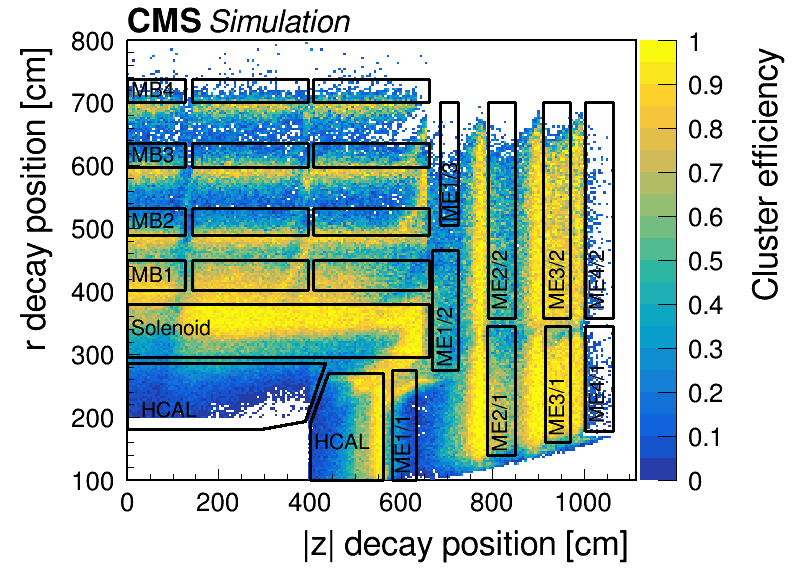

In [4]:
import numpy.ma as ma
import ROOT as rt
import os
import importlib
importlib.reload(sys.modules['CMS_lumi'])

# rt.gStyle.SetPaintTextFormat("6.3f")


for i, m in enumerate(samples):
    # if not 'Tau' in m:continue
    c = rt.TCanvas('c','c', 800, 600)
    bins = [14, 400+15, 15+1100, 13,100,750]#100-700, CSC analysis

#     bins = [30, -1115, 15+1100, 30,0,750]#100-700

#     bins = [200, 0, 15+1100, 200,100,750]#100-700
    bins = [200, 0, 15+1100, 200,100,800]#100-700
#     bins = [400, -1115, 15+1100, 200,100,750]#100-700


    title = ['r decay position [cm]', '|z| decay position [cm]']
    if bins[1]<0:
        hm = create_TH2D(np.column_stack((z_csc[m]+z_dt[m],r_csc[m]+r_dt[m])), 'hm1', axis_title = [title[1], title[0], 'Cluster efficiency'], binning=bins)
        hb = create_TH2D(np.column_stack((llp_z[m],llp_r[m])), 'hb1', axis_title = [title[1], title[0],'Cluster efficiency'], binning=bins)
    else:
        hm = create_TH2D(np.abs(np.column_stack((z_csc[m]+z_dt[m],r_csc[m]+r_dt[m]))), 'hm1', axis_title = [title[1], title[0], 'Cluster efficiency'], binning=bins)
        hb = create_TH2D(np.abs(np.column_stack((llp_z[m],llp_r[m]))), 'hb1', axis_title = [title[1], title[0],'Cluster efficiency'], binning=bins)

    pEff1 = rt.TEfficiency(hm,hb)
    hist = hm.Clone()
    
    for y in range(1, hm.GetYaxis().GetNbins()+1):
            nom = 0
            denom = 0
            for x in range(1, hm.GetXaxis().GetNbins()+1):
                global_bin = pEff1.GetGlobalBin(x,y)
                if pEff1.GetEfficiency(global_bin)<0.01:
                    pEff1.SetPassedEvents(global_bin, 0)
                if x==hm.GetXaxis().GetNbins():pEff1.SetPassedEvents(global_bin, 0)
                if hm.GetXaxis().GetBinCenter(x)>1063:pEff1.SetPassedEvents(global_bin, 0)

#                 if hm.GetYaxis().GetBinCenter(y)>738:pEff1.SetPassedEvents(global_bin, 0)
                if hm.GetYaxis().GetBinCenter(y)>700 and hm.GetXaxis().GetBinCenter(x)>661:pEff1.SetPassedEvents(global_bin, 0)

                hist.SetBinContent(x,y,pEff1.GetEfficiency(global_bin))
                if abs(hm.GetXaxis().GetBinCenter(x)) < 700:
#                     nom += hm.GetBinContent(x,y)
#                     denom += hb.GetBinContent(x,y)
                    
                    nom += pEff1.GetEfficiency(global_bin)
                    denom += 1
#             print(hm.GetYaxis().GetBinCenter(y), nom/denom)
                    

#     pEff1.Draw('colz')
    hist.SetMaximum(1.0)
    hist.Draw('colz')

    c.SetTopMargin(0.07)


    c.SetRightMargin(0.2)
    c.Draw()
    
    

    boxes = []
    # DT
    boxes.append(rt.TBox(max(bins[1],-661),402,126.8,449)) #MB1, wheel0
    boxes.append(rt.TBox(141.8,402,395.4,449)) #MB1, wheel1
    boxes.append(rt.TBox(407.4,402,661,449)) #MB1, wheel2

    boxes.append(rt.TBox(max(bins[1],-661),490,126.8,533)) #MB2
    boxes.append(rt.TBox(141.8,490,395.4,533)) #MB2
    boxes.append(rt.TBox(407.4,490,661,533)) #MB2

    boxes.append(rt.TBox(max(bins[1],-661),597,126.8,636)) #MB3
    boxes.append(rt.TBox(141.8,597,395.4,636)) #MB3
    boxes.append(rt.TBox(407.4,597,661,636)) #MB3
    
    boxes.append(rt.TBox(max(bins[1],-661),700,126.8,738)) #MB4
    boxes.append(rt.TBox(141.8,700,395.4,738)) #MB4
    boxes.append(rt.TBox(407.4,700,661,738)) #MB4

    boxes.append(rt.TBox(max(bins[1],-661),295,661,380)) #solenoid

    # +z mirror of CSC
    boxes.append(rt.TBox(791,357,850,700)) #ME2/2
    boxes.append(rt.TBox(911,357,970,700)) #ME3/2
    boxes.append(rt.TBox(1002,357,1063,700)) #ME4/2

    boxes.append(rt.TBox(789,139,850,345)) #ME2/1
    boxes.append(rt.TBox(915,160,970,345)) #ME3/1
    boxes.append(rt.TBox(1002,178,1063,345)) #ME4/1

    boxes.append(rt.TBox(580,100,632,275)) #ME1/1
    boxes.append(rt.TBox(668,275,724,465)) #ME1/2
    boxes.append(rt.TBox(686,505,724,700)) #ME1/3
    boxes.append(create_TGraph([400.5,560,560,440,400.5,400.5],[100.5,100.5,270,270,190,100.5])) #hcal endcap
    boxes.append(create_TGraph([433.2, 0.0,0.0,293.5, 390.5, 433.2],[286.4,286.4,181.1,181.1,194.1, 286.4])) #hcal barrel

    
    # -z mirror of CSC
    if bins[1]<0:
        boxes.append(rt.TBox(-791,357,-850,700)) #ME2/2
        boxes.append(rt.TBox(-911,357,-970,700)) #ME3/2
        boxes.append(rt.TBox(-1002,357,-1063,700)) #ME4/2

        boxes.append(rt.TBox(-789,139,-850,345)) #ME2/1
        boxes.append(rt.TBox(-915,160,-970,345)) #ME3/1
        boxes.append(rt.TBox(-1002,178,-1063,345)) #ME4/1

        boxes.append(rt.TBox(-580,100,-632,275)) #ME1/1
        boxes.append(rt.TBox(-668,275,-724,465)) #ME1/2
        boxes.append(rt.TBox(-686,505,-724,700)) #ME1/3
        boxes.append(create_TGraph([-400.5,-560,-560,-440,-400.5,-400.5],[100.5,100.5,270,270,190,100.5])) #hcal
        boxes.append(create_TGraph([-433.2, 0.0,0.0,-293.5, -390.5, -433.2],[286.4,286.4,181.1,181.1,194.1, 286.4])) #hcal barrel

    for b in boxes:
        b.SetFillColorAlpha(15,0)
        b.SetLineWidth(3)
        b.SetLineColor(1)
    #     b.SetFillStyle(3001)
        b.Draw('l same')

    steel = []
    steel.append(rt.TBox(max(bins[1],-661),380,126.8,402)) #MB1, wheel0


    steel.append(rt.TBox(max(bins[1],-661),449,126.8,490)) #MB1, wheel0
    steel.append(rt.TBox(141.8,449,395.4,490)) #MB1, wheel1
    steel.append(rt.TBox(407.4,449,661,490)) #MB1, wheel2
    
    steel.append(rt.TBox(max(bins[1],-661),533,126.8,597)) #MB2
    steel.append(rt.TBox(141.8,533,395.4,597)) #MB2
    steel.append(rt.TBox(407.4,533,661,597)) #MB2
    
    steel.append(rt.TBox(max(bins[1],-661),636,126.8,700)) #MB3
    steel.append(rt.TBox(141.8,636,395.4,700)) #MB3
    steel.append(rt.TBox(407.4,636,661,700)) #MB3
    
    x=[633,633, 1100, 1100, 1075, 1075, 1063, 1063,1002,1002,975,975,912,912,849,849,789,789,724,724, 633]
    y=[275, 100, 100, 150, 150, 700,700,150,150,700,700,140,140,700,700,110,110,700,700,275,275]
    steel.append(create_TGraph(x,y)) 



#     for b in steel:
#         b.SetFillColorAlpha(15,0.5)
#         b.Draw('fsame')

    
    text = rt.TLatex()
    text.SetTextSize(0.04)

    

    text.DrawLatex(bins[1]+10, 415, "MB1")
    text.DrawLatex(bins[1]+10, 500, "MB2")
    text.DrawLatex(bins[1]+10, 605, "MB3")
    text.DrawLatex(bins[1]+10, 708, "MB4")

#     text.DrawLatex(650, 140, "Steel")
#     text.DrawLatex(bins[1]+10,660, "Steel")
    text.DrawLatex(bins[1]+10, 330, "Solenoid")
    text.DrawLatex(bins[1]+30, 200, "HCAL")
    text.DrawLatex(410, 150, "HCAL")

    text.SetTextAngle(90)
    ring2_r = 370
    text.DrawLatex(620, 110, "ME1/1")
    text.DrawLatex(712, 280, "ME1/2")
    text.DrawLatex(722, 510, "ME1/3")

    text.DrawLatex(832, 145, "ME2/1")
    text.DrawLatex(832, ring2_r, "ME2/2")

    text.DrawLatex(957, 170, "ME3/1")
    text.DrawLatex(957, ring2_r, "ME3/2")

    text.DrawLatex(1045, 190, "ME4/1")
    text.DrawLatex(1045, ring2_r, "ME4/2")
#     tdrstyle.setTDRStyle()
#     CMS_lumi.cmsText     = "CMS"
#     iPos = 0
#     CMS_lumi.writeExtraText = 1
#     CMS_lumi.extraText   = "Simulation"
#     CMS_lumi.extraText   = "Simulation Preliminary"

#     CMS_lumi.extraRelDX=0.0

#     CMS_lumi.extraRelDY=0.0

#     if( iPos==0 ): CMS_lumi.relPosX = 0.15
#     # CMS_lumi.CMS_lumi(c, 4, 0)
#     CMS_lumi.CMS_lumi(c, 0, 0)
    tdrstyle.setTDRStyle()
    CMS_lumi.cmsText     = "CMS"
    CMS_lumi.writeExtraText = 1
    CMS_lumi.extraText ='Simulation'

#     CMS_lumi.extraText ='Simulation Preliminary'

    iPos = 0
    if( iPos==0 ): CMS_lumi.relPosX = 0.12
    CMS_lumi.relExtraDX =0.02


    CMS_lumi.CMS_lumi(c, 0, iPos)

    if CMS_lumi.extraText == 'Simulation Preliminary':
        c.SaveAs(GIT_REPO + "/plots/cluster_eff/2D_sig_eff_"+m+"_pas.C")
        c.SaveAs(GIT_REPO + "/plots/cluster_eff/2D_sig_eff_"+m+"_pas.pdf")
        c.SaveAs(GIT_REPO + "/plots/cluster_eff/2D_sig_eff_"+m+"_pas.png")  
    else:
        c.SaveAs(GIT_REPO + "/plots/cluster_eff/2D_sig_eff_"+m+".C")
        c.SaveAs(GIT_REPO + "/plots/cluster_eff/2D_sig_eff_"+m+".pdf")
        c.SaveAs(GIT_REPO + "/plots/cluster_eff/2D_sig_eff_"+m+".png")

In [6]:
def load_csc():
    boxes = []
    boxes.append(rt.TBox(xmin,ymin,568,ymax)) #in front of ME11
    boxes.append(rt.TBox(632,ymin,671,ymax)) #between ME11 and ME12
    boxes.append(rt.TBox(724,ymin,789,ymax)) #between ME12 and station2
    boxes.append(rt.TBox(849,ymin,911,ymax)) #between station2 and station3
    boxes.append(rt.TBox(970,ymin,1002,ymax)) #between station3 and station4
    # boxes.append(rt.TBox(1073,ymin,xmax,ymax)) #beyond CMS
    for b in boxes:
        b.SetFillColorAlpha(15,0.5)
        b.Draw('same')

    line = rt.TLine(1073,ymin,1073,ymax);
    line.SetLineStyle(2)
    line.SetLineWidth(3)
    line.Draw()

    l = rt.TLatex()
    l.SetTextSize(0.08)
    l.SetTextColor(12)
    l.SetTextAngle(90)
    l.SetTextFont(42)
    l.DrawLatex(xmin+80, ymax*0.4, "Steel")

    l2 = rt.TLatex()
    l2.SetTextSize(0.06)
    # l2.SetTextColor(13)
    l2.SetTextAngle(90)
    l2.SetTextFont(42)
    l2.DrawLatex(1110, ymax*0.5, "Beyond CMS")


    text = rt.TLatex()
    text.SetTextSize(0.04)
    text.SetTextFont(42)
    text.DrawLatex(570, ymax*1.01, "ME1/1")
    text.DrawLatex(660, ymax*1.01, "ME1/2-3")
    text.DrawLatex(795, ymax*1.01, "ME2")
    text.DrawLatex(920, ymax*1.01, "ME3")
    text.DrawLatex(1015, ymax*1.01, "ME4")
    return boxes
def load_dt():
    

    boxes = []

    boxes.append(rt.TBox(295,ymin,379,ymax)) #solenoid
    boxes.append(rt.TBox(380,ymin,418,ymax)) #in front of MB1 380 - 402
    boxes.append(rt.TBox(466,ymin,498,ymax)) #between MB1 and MB2, 449-490?
    boxes.append(rt.TBox(546,ymin,606,ymax)) #between MB2 and MB3, 533 -- 597
    boxes.append(rt.TBox(656,ymin,708,ymax)) #between MB3 and MB4 636--700

    for i, b in enumerate(boxes):
        if i == 0:
            b.SetFillColorAlpha(15,0.2)
        else:
            b.SetFillColor(15)
            b.SetFillColorAlpha(15,0.5)
        b.Draw('same')


    line = rt.TLine(738,ymin,738,ymax);
    line.SetLineStyle(2)
    # line.SetLineColor(15)
    line.SetLineWidth(3)
    line.Draw()


    l2 = rt.TLatex()
    l2.SetTextSize(0.06)
    # l2.SetTextColor(13)
    l2.SetTextAngle(90)
    l2.SetTextFont(42)
    l2.DrawLatex(780, ymax*0.5, "Beyond CMS")

    l = rt.TLatex()
    l.SetTextSize(0.08)
    l.SetTextColor(13)
    l.SetTextAngle(90)
    l.SetTextFont(42)
    l.DrawLatex(350, ymax*0.15, "Magnet")

    l2 = rt.TLatex()
    l2.SetTextSize(0.06)
    l2.SetTextColor(12)
    l2.SetTextAngle(90)
    l2.SetTextFont(42)
    l2.DrawLatex(690, ymax*0.1, "Steel")
    text = rt.TLatex()
    text.SetTextSize(0.04)
    text.SetTextFont(42)
    text.DrawLatex(405, ymax*1.01, "MB1")
    text.DrawLatex(490, ymax*1.01, "MB2")
    text.DrawLatex(595, ymax*1.01, "MB3")
    text.DrawLatex(700, ymax*1.01, "MB4")
    return line, boxes

In [8]:
write_ROOT = 0

# 1d efficiency, all samples in 1 plot

False



Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/cluster_eff/csc_1D_sig_eff_4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.C has been generated
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/cluster_eff/csc_1D_sig_eff_4Tau_MH-125-MS-15-ctauS-1000_TuneCP

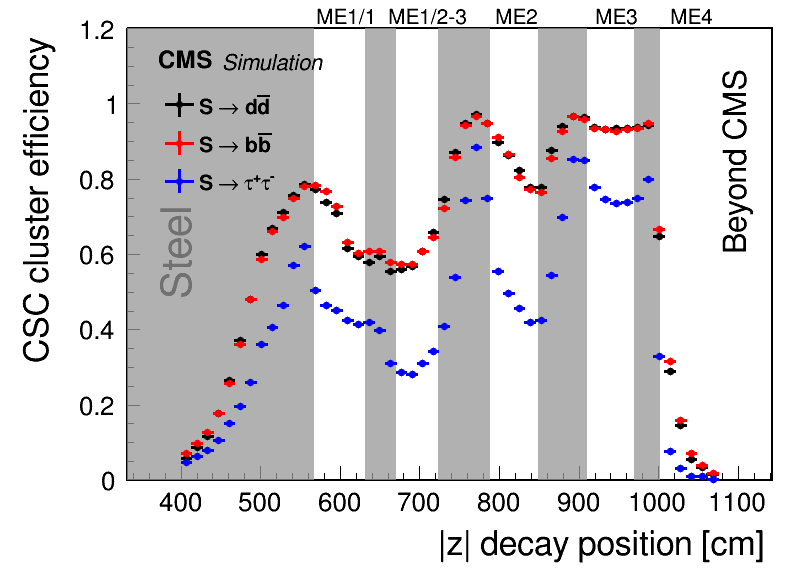

In [9]:
import numpy.ma as ma
import ROOT as rt
import os
import importlib
importlib.reload(sys.modules['CMS_lumi'])

bins = [50, 400, 1075]
xaxis_title = '|z| decay position [cm]'

leg = rt.TLegend(0.2,0.65,0.4,0.85)
leg.SetTextSize(0.04)
leg.SetBorderSize(0)
leg.SetEntrySeparation(0.01)
leg.SetFillStyle(0)

c = rt.TCanvas('c','c', 800, 600)
pEff= {}
for i,m in enumerate(samples):
    if not 'd' in m:continue
    hm = create_TH1D(np.abs(z_csc[m]), 'hb1', axis_title = [xaxis_title,'CSC cluster efficiency'], binning=bins)
    hb = create_TH1D(np.abs(llp_z_csc[m]), 'hb1', axis_title = [xaxis_title,'CSC cluster efficiency'], binning=bins)
    # hm = create_TH1D(np.abs(r_dt[m]), 'hb1', axis_title = [xaxis_title,'DT cluster efficiency'], binning=bins)
    # hb = create_TH1D(np.abs(llp_r_dt[m]), 'hb1', axis_title = [xaxis_title,'DT cluster efficiency'], binning=bins)
    pEff[m] = rt.TEfficiency(hm,hb)
    pEff[m].SetLineColor(std_color_list[i])
    pEff[m].SetMarkerColor(std_color_list[i])
    pEff[m].SetLineWidth(3)

    if 'E' in m:leg.AddEntry(pEff[m], 'S #rightarrow e^{+}e^{-}','lpe3')
    elif 'D' in m:leg.AddEntry(pEff[m], 'S #rightarrow d#bar{d}','LPE4')
    elif 'Tau' in m:leg.AddEntry(pEff[m], 'S #rightarrow #tau^{+}#tau^{-}','LPE4')
    else:leg.AddEntry(pEff[m], 'S #rightarrow b#bar{b}','LPE5')
        
        
    pEff[m].Draw('' if i == 0 else 'Psame')
c.Draw()
    
pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetYaxis().SetTitleOffset(0.0);
if write_ROOT:
    outputDir = '/storage/af/user/christiw/login-1/christiw/LLP/CMSSW_9_4_4/src/llp_analyzer/data/SupplementaryMaterials/combination/'
    if not os.path.isfile(outputDir+'hepdata.root'):outFile = rt.TFile(outputDir+'hepdata.root', 'RECREATE')
    else: outFile = rt.TFile(outputDir+'hepdata.root', 'UPDATE')
    outFile.WriteTObject(pEff[list(pEff.keys())[0]], 'CSCcluster_eff', "WriteDelete");
    outFile.Close();

ymax = pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetMaximum()
ymin = pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetMinimum()
xmin = pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetXaxis().GetXmin()
xmax = pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetXaxis().GetXmax()
ymax = 1.2
ymin = 0
pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMaximum(ymax)
pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMinimum(ymin)

boxes = load_csc()
for b in boxes:
    b.SetFillColorAlpha(15,0.5)
    b.Draw('same')


CMS_lumi.cmsText     = "CMS"
CMS_lumi.relPosX = 0.09
CMS_lumi.relPosY = 0.0
CMS_lumi.writeExtraText = 1
CMS_lumi.extraText   = "Simulation"
# CMS_lumi.extraText   = "Simulation Preliminary"

CMS_lumi.relPosX = 0.05
CMS_lumi.relPosY = 0.05
CMS_lumi.relExtraDY = 0.07
CMS_lumi.relExtraDX = 0.08
CMS_lumi.CMS_lumi(c, 0, 10)



for k,v in pEff.items():pEff[k].Draw('same')
leg.Draw()
c.SetRightMargin(0.03)


c.Draw()


if CMS_lumi.extraText == 'Simulation Preliminary':
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/csc_1D_sig_eff_"+m+"_pas.C")
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/csc_1D_sig_eff_"+m+"_pas.pdf")
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/csc_1D_sig_eff_"+m+"_pas.png")

else:
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/csc_1D_sig_eff_"+m+".C")
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/csc_1D_sig_eff_"+m+".pdf")
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/csc_1D_sig_eff_"+m+".png")


# DT signal efficiency

False



Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: hb1 (Potential memory leak).
Info in <TCanvas::SaveSource>: C++ Macro file: /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/cluster_eff/dt_1D_sig_eff_4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_13p6TeV_powheg-pythia8_50000pb_weighted.C has been generated
Info in <TCanvas::Print>: pdf file /storage/af/user/christiw/login-1/christiw/LLP/Run3/CMSSW_14_0_1/src/mds_analysis/plots/cluster_eff/dt_1D_sig_eff_4Tau_MH-125-MS-15-ctauS-1000_TuneCP5_

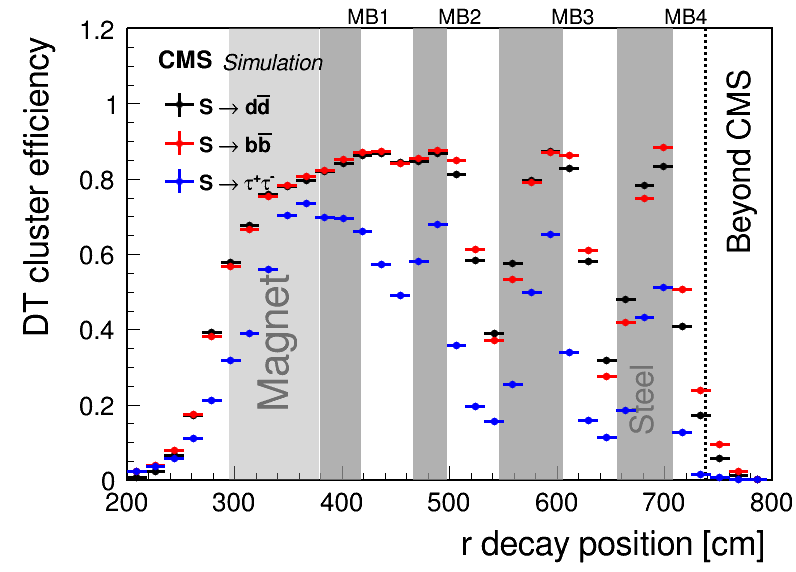

In [11]:

c = rt.TCanvas('c','c', 800, 600)

    
bins = [50, 200, 1075]
xaxis_title = 'r decay position [cm]'

leg = rt.TLegend(0.2,0.65,0.4,0.85)
leg.SetTextSize(0.04)
leg.SetBorderSize(0)
leg.SetEntrySeparation(0.01)
leg.SetFillStyle(0)

pEff= {}
for i,m in enumerate(samples):
    hm = create_TH1D(np.abs(r_dt[m]), 'hb1', axis_title = [xaxis_title,'DT cluster efficiency'], binning=bins)
    hb = create_TH1D(np.abs(llp_r_dt[m]), 'hb1', axis_title = [xaxis_title,'DT cluster efficiency'], binning=bins)
    pEff[m] = rt.TEfficiency(hm,hb)
    pEff[m].SetLineColor(std_color_list[i])
    pEff[m].SetMarkerColor(std_color_list[i])
    pEff[m].SetLineWidth(3)

    if 'E' in m:leg.AddEntry(pEff[m], 'S #rightarrow e^{+}e^{-}','lpe3')
    elif 'D' in m:leg.AddEntry(pEff[m], 'S #rightarrow d#bar{d}','LPE4')
    elif 'Tau' in m:leg.AddEntry(pEff[m], 'S #rightarrow #tau^{+}#tau^{-}','LPE4')
    else:leg.AddEntry(pEff[m], 'S #rightarrow b#bar{b}','LPE5')
 
    pEff[m].Draw('' if i == 0 else 'Psame')

c.Draw()


pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetXaxis().SetLimits(200,800)
xmin = pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetXaxis().GetXmin()
xmax = pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetXaxis().GetXmax()
ymax = 1.2
ymin = 0
pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMaximum(ymax)
pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().SetMinimum(ymin)
pEff[list(pEff.keys())[0]].GetPaintedGraph().GetHistogram().GetYaxis().SetTitleOffset(0.0);




line, boxes = load_dt()
for i, b in enumerate(boxes):
    if i == 0:
        b.SetFillColorAlpha(15,0.2)
    else:
        b.SetFillColor(15)
        b.SetFillColorAlpha(15,0.5)
    b.Draw('same')
line.Draw('same')

CMS_lumi.cmsText     = "CMS"
CMS_lumi.relPosX = 0.09
CMS_lumi.relPosY = 0.0
CMS_lumi.writeExtraText = 1
CMS_lumi.extraText   = "Simulation"
# CMS_lumi.extraText   = "Simulation Preliminary"

    
CMS_lumi.relPosX = 0.05
CMS_lumi.relPosY = 0.05
CMS_lumi.relExtraDY = 0.07
CMS_lumi.relExtraDX = 0.08
CMS_lumi.CMS_lumi(c, 0, 10)


c.SetRightMargin(0.03)
for k,v in pEff.items():pEff[k].Draw('same')
leg.Draw()

c.Draw()


if CMS_lumi.extraText == 'Simulation Preliminary':
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/dt_1D_sig_eff_"+m+"_pas.C")
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/dt_1D_sig_eff_"+m+"_pas.pdf")
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/dt_1D_sig_eff_"+m+"_pas.png")

else:
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/dt_1D_sig_eff_"+m+".C")
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/dt_1D_sig_eff_"+m+".pdf")
    c.SaveAs(GIT_REPO + "/plots/cluster_eff/dt_1D_sig_eff_"+m+".png")

